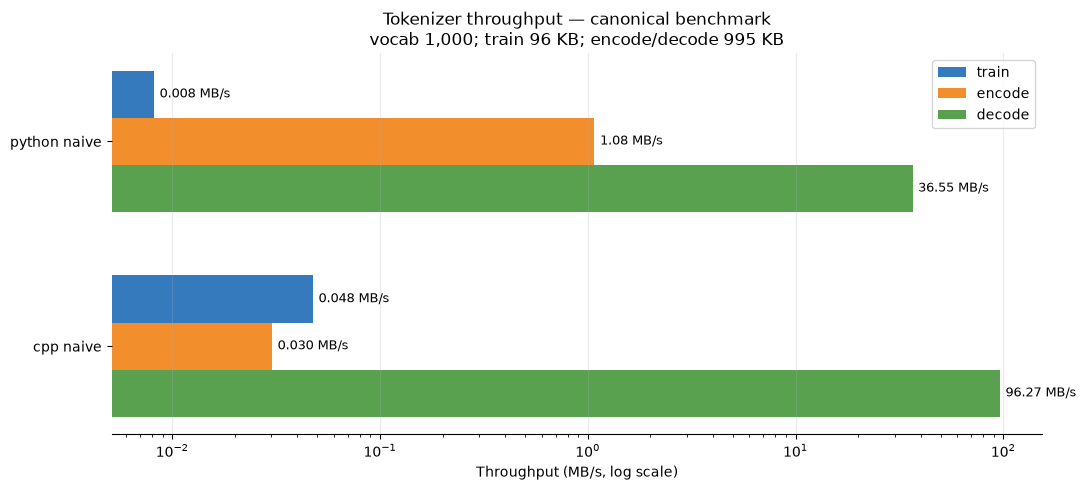

In [11]:
%matplotlib inline

import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

records = [
    json.loads(line)
    for line in Path("benchmarks.jsonl").read_text().splitlines()
    if line.strip()
]

latest = {
    (record["label"], record["operation"]): record
    for record in records
}

operations = ["train", "encode", "decode"]
implementations = list(dict.fromkeys(record["label"] for record in records))

implementations = [
    name
    for name in implementations
    if all((name, operation) in latest for operation in operations)
]

def format_speed(speed):
    if speed >= 1000:
        return f"{speed / 1000:.2f} GB/s"
    if speed < 0.1:
        return f"{speed:.3f} MB/s"
    return f"{speed:.2f} MB/s"

y = np.arange(len(implementations))
height = 0.23
colors = ["#357ABD", "#F28E2B", "#59A14F"]

figure, axis = plt.subplots(figsize=(11, 5))

for index, operation in enumerate(operations):
    speeds = [
        latest[(name, operation)]["median_throughput_bytes_per_second"]
        / 1_000_000
        for name in implementations
    ]

    bars = axis.barh(
        y + (index - 1) * height,
        speeds,
        height,
        label=operation,
        color=colors[index],
    )

    axis.bar_label(
        bars,
        labels=[format_speed(speed) for speed in speeds],
        padding=4,
        fontsize=9,
    )

axis.set_yticks(
    y,
    [name.replace("-", " ") for name in implementations],
)

axis.set_xscale("log")
axis.set_xlabel("Throughput (MB/s, log scale)")
axis.set_title(
    "Tokenizer throughput — canonical benchmark\n"
    "vocab 1,000; train 96 KB; encode/decode 995 KB"
)

axis.invert_yaxis()
axis.grid(axis="x", alpha=0.25)
axis.legend()
axis.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()